## Part 1: Analysis workflow

In this exercise we are going to use a dataset from the CMS Open Data portal. It is a DoubleMuon primary dataset in NANOAOD format from RunG of 2016. Run period from run number 278820 to 280385. [1] It contains muon data from events from CMS collisions with at least 2 muons.

NANOAOD datasets are in the ROOT tree format. This is a flat data structure, where we have for each collision (event) a list of muon particles that were reconstructed from the recorded detector signals. For each particle, we have a list of measured variables. Each of this variables is a "brnch" of the ROOT tree. 

[1] https://opendata.cern.ch/record/30522

In [1]:
cd ~/work/CmsOpenData/RDFAnalyzer; pwd

[Errno 2] No such file or directory: '/home/lopezr/work/CmsOpenData/RDFAnalyzer; pwd'
/home/lopezr/Documents/work/teaching/CmsOpenData/RDFAnalyzer


In [2]:
# Import ROOT (ROOT is a analysis package used to handle 
# the tree files, but also histograms, etc.)
import ROOT as R
%jsroot off
from utils import histpars, loadRDF, plot

In [3]:
R.gROOT.ProcessLine('.L ./_tdrstyle.C')
R.setTDRStyle()
R.gROOT.SetBatch(1)

In [4]:
# Load the data into an RDataFrame structure
df = loadRDF("Events",
    "../data_skimmed/Run2016G_DoubleMuon_NANOAOD_UL2016_MiniAODv2_NanoAODv9-v2_2430000_05DD095C-F6C3-9A4F-9FB3-348A5A6403D5_skimmed.root")

In [5]:
print("\nList of histograms to be produced:\n")
for var in histpars:
    print(f"{var:18} : {histpars[var]['name']:40}")


List of histograms to be produced:

nMuon              : Number of muons in the event            
Muon_dxy           : Muon impact parameter in the XY plane [GeV]
Muon_dz            : Muon impact parameter in the Z axis [GeV]
Muon_eta           : Muon trajectory pseudorrapidity (#eta)  
Muon_phi           : Muon trajectory #phi coordinate         
Muon_pt            : Muon transverse momentum (p_{T}) [GeV]  
Muon_charge        : Muon charge                             
Muon_isTracker     : Muon is reconstructed by tracker algorithm?
Muon_isStandalone  : Muon is reconstructed by standalone algorithm?
Muon_isGlobal      : Muon is reconstructed by global algorithm?
DiMuon_invMass     : Dimuon invariant mass [GeV]             


In [6]:
# Make all histograms
hists = {}
for variable in histpars:
    print(f"Making histogram {variable}...")
    _xlabel = histpars[variable]["xlabel"]
    _bins   = histpars[variable]["bins"]
    _xmin   = histpars[variable]["xmin"]
    _xmax   = histpars[variable]["xmax"]
    h = df.Histo1D((f"h_{variable}",f";{_xlabel};Events", _bins, _xmin, _xmax), variable)
    hists[variable] = h

print("Writing to file...")
fwrite = R.TFile.Open("temp/hists_raw.root","RECREATE")
for variable in histpars:
    hists[variable].Write()
fwrite.Close()

print("Done!")

Making histogram nMuon...
Making histogram Muon_dxy...
Making histogram Muon_dz...
Making histogram Muon_eta...
Making histogram Muon_phi...
Making histogram Muon_pt...
Making histogram Muon_charge...
Making histogram Muon_isTracker...
Making histogram Muon_isStandalone...
Making histogram Muon_isGlobal...
Making histogram DiMuon_invMass...
Writing to file...
Done!


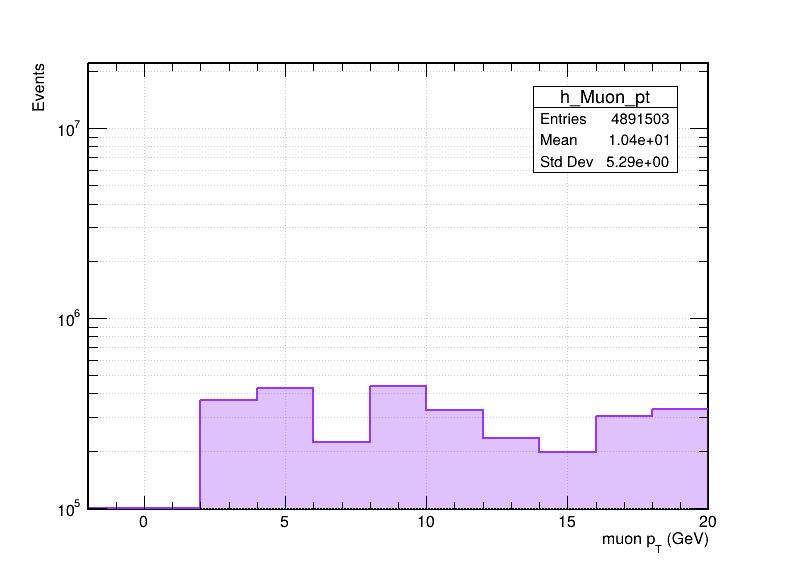

In [7]:
# Insert variable to read
variable = "Muon_pt"

fread = R.TFile.Open("temp/hists_raw.root","READ")
h = fread.Get(f"h_{variable}")
h.SetDirectory(0)
fread.Close()

R.gROOT.FindObject(f"c_{variable}") and R.gROOT.FindObject(f"c_{variable}").Close() # Avoid memory conflicts and crashes
c = R.TCanvas(f"c_{variable}","")
c = plot(c, h)
h.GetXaxis().SetRange(0,10)
c.Draw()